---

# Density-Based Clustering with DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups points based on density rather than distance to a centroid. Unlike K-Means, it does not require the number of clusters to be specified in advance and can identify arbitrarily shaped clusters as well as outliers.

The algorithm relies on two parameters:
- **epsilon (ε)** — the radius of the neighborhood around each point
- **min_samples (k)** — the minimum number of points required within ε for a point to be considered a core point

Points that cannot be reached by any core point are labeled as noise (outliers).

In this notebook, we apply DBSCAN to the Mall Customer dataset to identify natural groupings of customers based on their annual income and spending score.

---

In [12]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own DBSCAN implementation from ml_pack
from ml_pack import DBSCAN

# Sklearn only used for preprocessing
from sklearn.preprocessing import StandardScaler

---

## Loading and Exploring the Data

Let's load the Mall Customer dataset and take a first look at its structure.

---

In [13]:
# Load the Mall Customer dataset
df = pd.read_csv("Mall_Customers.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


---

## Selecting Features

We'll cluster customers based on their **Annual Income** and **Spending Score** since these two features capture the most meaningful behavioral patterns. CustomerID and Gender won't be useful for clustering.

---

In [15]:
# Select the two features we want to cluster on
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("Feature matrix shape:", X.shape)

Feature matrix shape: (200, 2)


---

## Scaling the Data

DBSCAN uses distance calculations to determine neighborhoods, so it's important to standardize the features so that differences in scale don't bias the results.

---

In [16]:
# Standardize features to have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---

## Applying DBSCAN

We apply DBSCAN with epsilon=0.5 and min_samples=5. Points labeled -1 are considered noise/outliers by the algorithm.

---

In [17]:
# Apply our custom DBSCAN implementation
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Summarize results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers found: {n_outliers}")

Number of clusters found: 2
Number of outliers found: 8


---

## Visualizing the Clusters

Let's plot the clusters and highlight the outliers identified by DBSCAN.

---

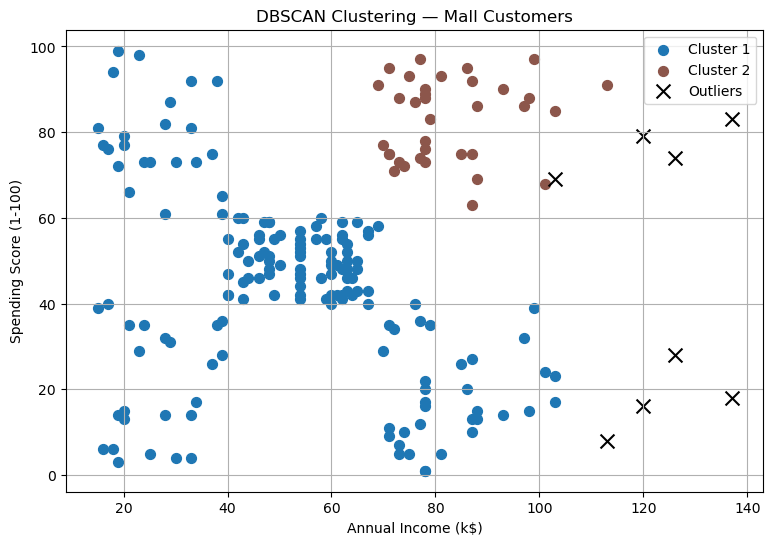

In [18]:
# Plot the clustering results
plt.figure(figsize=(9, 6))

# Get unique labels and assign colors
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Outliers plotted as black x markers
        mask = labels == label
        plt.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', s=100, label='Outliers')
    else:
        mask = labels == label
        plt.scatter(X[mask, 0], X[mask, 1], color=color, s=50, label=f'Cluster {label + 1}')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering — Mall Customers")
plt.legend()
plt.grid(True)
plt.show()

---

## Effect of Hyperparameters

The results of DBSCAN are sensitive to the choice of epsilon and min_samples. Let's visualize how different epsilon values affect the clustering.

---

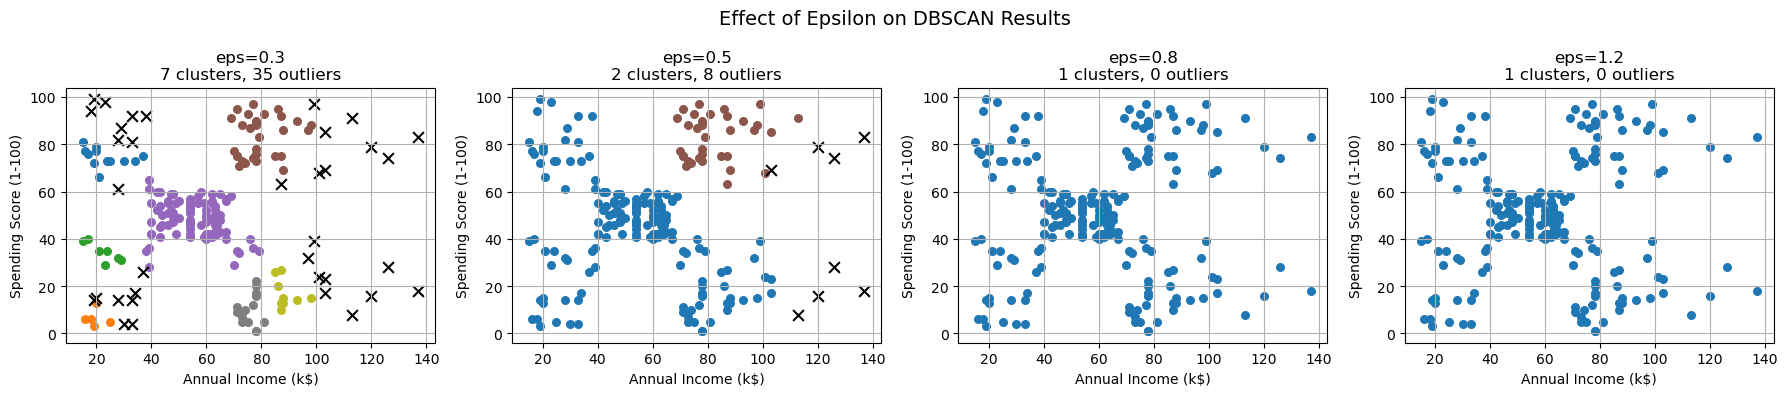

In [19]:
# Compare different epsilon values
eps_values = [0.3, 0.5, 0.8, 1.2]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps in zip(axes, eps_values):
    model = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = model.fit_predict(X_scaled)

    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_outliers = list(cluster_labels).count(-1)

    # Plot each configuration
    unique = set(cluster_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique)))

    for label, color in zip(unique, colors):
        if label == -1:
            mask = cluster_labels == label
            ax.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', s=60)
        else:
            mask = cluster_labels == label
            ax.scatter(X[mask, 0], X[mask, 1], color=color, s=30)

    ax.set_title(f"eps={eps}\n{n_clusters} clusters, {n_outliers} outliers")
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.grid(True)

plt.suptitle("Effect of Epsilon on DBSCAN Results", fontsize=14)
plt.tight_layout()
plt.show()

---

## Analyzing the Outliers

Let's take a closer look at the customers identified as outliers by DBSCAN to understand what makes them unusual.

---

In [20]:
# Add cluster labels back to the original dataframe
df['Cluster'] = labels

# Separate outliers from clustered points
outliers = df[df['Cluster'] == -1]
clustered = df[df['Cluster'] != -1]

print(f"Total outliers: {len(outliers)}")
print(f"Total clustered points: {len(clustered)}")
print()
print("Outlier customer profiles:")
outliers[['Annual Income (k$)', 'Spending Score (1-100)', 'Age', 'Gender']].describe()

Total outliers: 8
Total clustered points: 192

Outlier customer profiles:


,Annual Income (k$),Spending Score (1-100),Age
count,8.000000,8.000000,8.000000
mean,122.750000,46.875000,35.750000
std,11.510864,32.108911,6.497252
min,103.000000,8.000000,30.000000
25%,118.250000,17.500000,32.000000
50%,123.000000,48.500000,32.500000
75%,128.750000,75.250000,37.500000
max,137.000000,83.000000,47.000000


---

The 8 outliers tend to have **high annual incomes** (averaging $122k) but highly variable spending scores, ranging from very low (8) to relatively high (83). This suggests these customers don't fit neatly into any spending pattern — some are high earners who spend very little, while others spend a lot despite similar incomes. In a real business setting, these outliers might warrant individual attention from a marketing team.

---

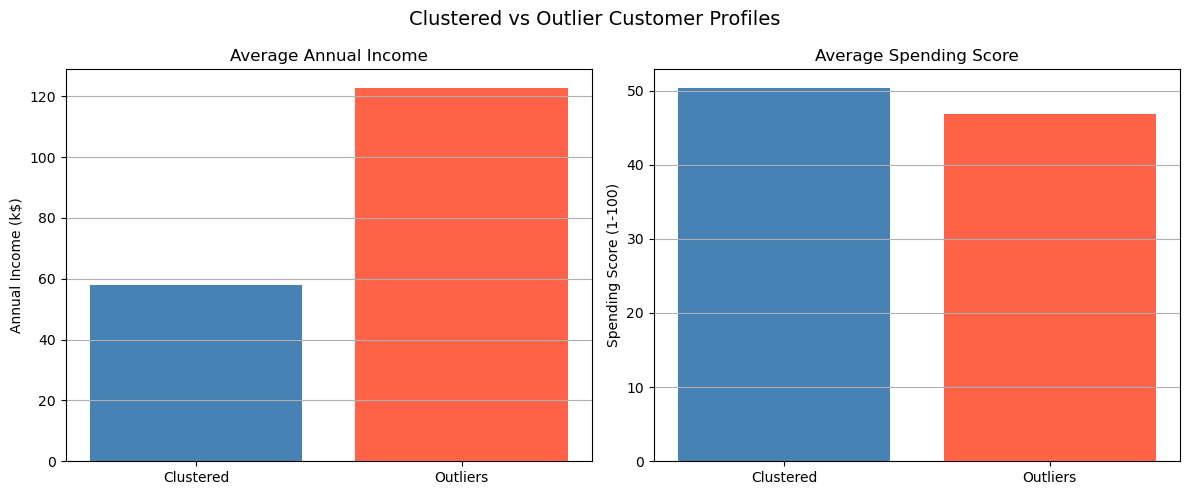

In [21]:
# Compare average profiles of clustered vs outlier customers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Annual Income comparison
axes[0].bar(['Clustered', 'Outliers'],
            [clustered['Annual Income (k$)'].mean(), outliers['Annual Income (k$)'].mean()],
            color=['steelblue', 'tomato'])
axes[0].set_title("Average Annual Income")
axes[0].set_ylabel("Annual Income (k$)")
axes[0].grid(True, axis='y')

# Spending Score comparison
axes[1].bar(['Clustered', 'Outliers'],
            [clustered['Spending Score (1-100)'].mean(), outliers['Spending Score (1-100)'].mean()],
            color=['steelblue', 'tomato'])
axes[1].set_title("Average Spending Score")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].grid(True, axis='y')

plt.suptitle("Clustered vs Outlier Customer Profiles", fontsize=14)
plt.tight_layout()
plt.show()

---

## Summary

In this notebook, we applied DBSCAN to the Mall Customer dataset to identify natural groupings and outliers based on annual income and spending score. With epsilon=0.5 and min_samples=5, the algorithm identified 2 clusters and 8 outliers.

Key takeaways:
- DBSCAN does not require specifying the number of clusters in advance
- Points in low-density regions are automatically labeled as outliers
- The choice of epsilon significantly impacts the results — too small and most points become outliers, too large and everything merges into one cluster
- Unlike K-Means, DBSCAN can handle irregularly shaped clusters
- The 8 outliers identified were high-income customers with highly variable spending behavior, suggesting they don't fit typical customer profiles and may warrant individual attention

---
